# Steel Industry Energy Consumption Analysis ⚡
### Machine Learning Project
- Objective: Predict energy consumption in a steel manufacturing plant to optimize electricity usage and reduce operational costs
- Algorithms Used : KNN , Decision Tree , Linear Regression , Random Forest , Ada Boosting , Gradient Boosting , XG boosting

## Problem Statement
Energy consumption in steel industries is high and costly.
We aim to predict energy usage based on various operational features.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# importing libaries

In [9]:
df = pd.read_csv("Steel_industry_data.csv")
#load the dataset

### Data Understanding

In [10]:
df
# display of dataset

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


### Understanding of columns

Usage_kWh  : Electrical energy consumed by industry ,measures in kilowatt/hour [Taregt Variable],

Lagging_Current_Reactive.Power_kVarh : Reactive power from Inductive loads

Leading_Current_Reactive_Power_kVarh : Reactive power from capacitive loads

CO2(tCO2)  : Carbon emission from Energy consumption

Lagging_Current_Power_Factor : Power Factor measured for efficiency

Leading_Current_Power_Factor : Power factor measure for efficiency

NSM : Number of seconds From Midnight ,Captures time of day pattern 

WeekStatus : Industry behaves different on weekends

Day_of_week : Captures weekly patterns

Load_Type : Whether its low,high load depending on energy consumption


In [12]:
df.shape #shape of the dataset

(35040, 11)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

## Data Preprocessing

### Data Cleaning

In [14]:
df.isnull().sum() # check with missing values

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

In [15]:
df.duplicated().sum() # check with duplicate values

np.int64(0)

In [16]:
df.columns = df.columns.str.strip().str.replace('.', '_', regex=False)
# Lagging_Current_Reactive.Power_kVarh changing this to Lagging_Current_Reactive_Power_kVarh

In [17]:
df = df.drop("Load_Type", axis=1)
# Dropping Load_Type because it derived from energy consumption and could cause data leakage risk.

In [18]:
df = df.drop("CO2(tCO2)",axis=1)
# Dropping CO2(tCO2) because its Carbon emission energy usage and not used for energy prediction usage

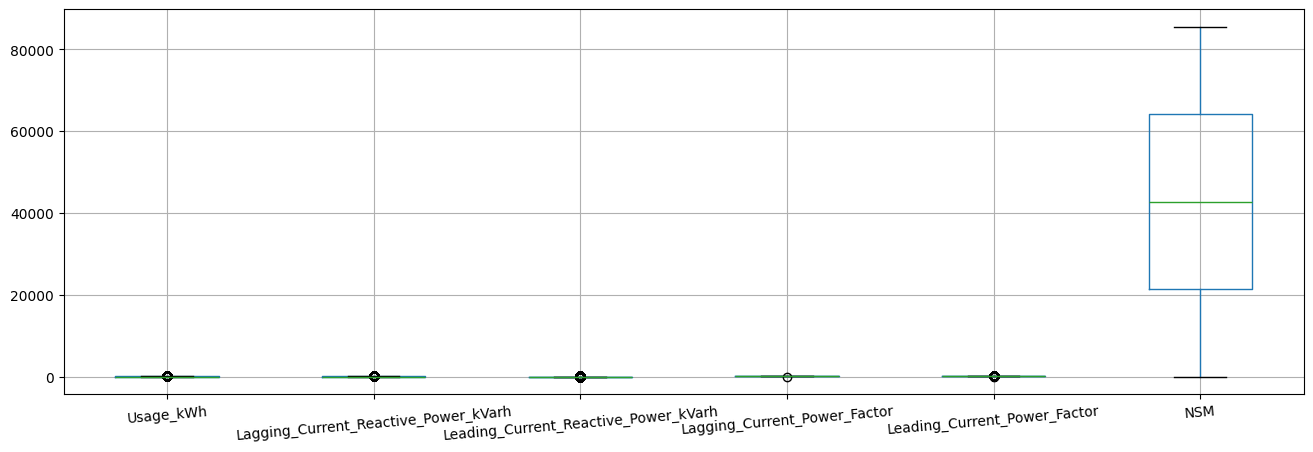

In [19]:
df.boxplot(figsize=(16,5))
plt.xticks(rotation=5)
plt.show()
# boxplot helps in detecting outliers

In [20]:
# Detecting outliers using IQR for better understanding of the detail number of outliers and they lower,upper bound values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print("-------",col,"-------")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", outliers.shape[0])


------- Usage_kWh -------
Lower Bound: -68.85624999999999
Upper Bound: 123.29374999999999
Number of Outliers: 328
------- Lagging_Current_Reactive_Power_kVarh -------
Lower Bound: -28.209999999999997
Upper Bound: 53.15
Number of Outliers: 1059
------- Leading_Current_Reactive_Power_kVarh -------
Lower Bound: -3.135
Upper Bound: 5.225
Number of Outliers: 7759
------- Lagging_Current_Power_Factor -------
Lower Bound: 9.766250000000007
Upper Bound: 152.57625
Number of Outliers: 1
------- Leading_Current_Power_Factor -------
Lower Bound: 99.25
Upper Bound: 100.44999999999999
Number of Outliers: 8327
------- NSM -------
Lower Bound: -42750.0
Upper Bound: 128250.0
Number of Outliers: 0


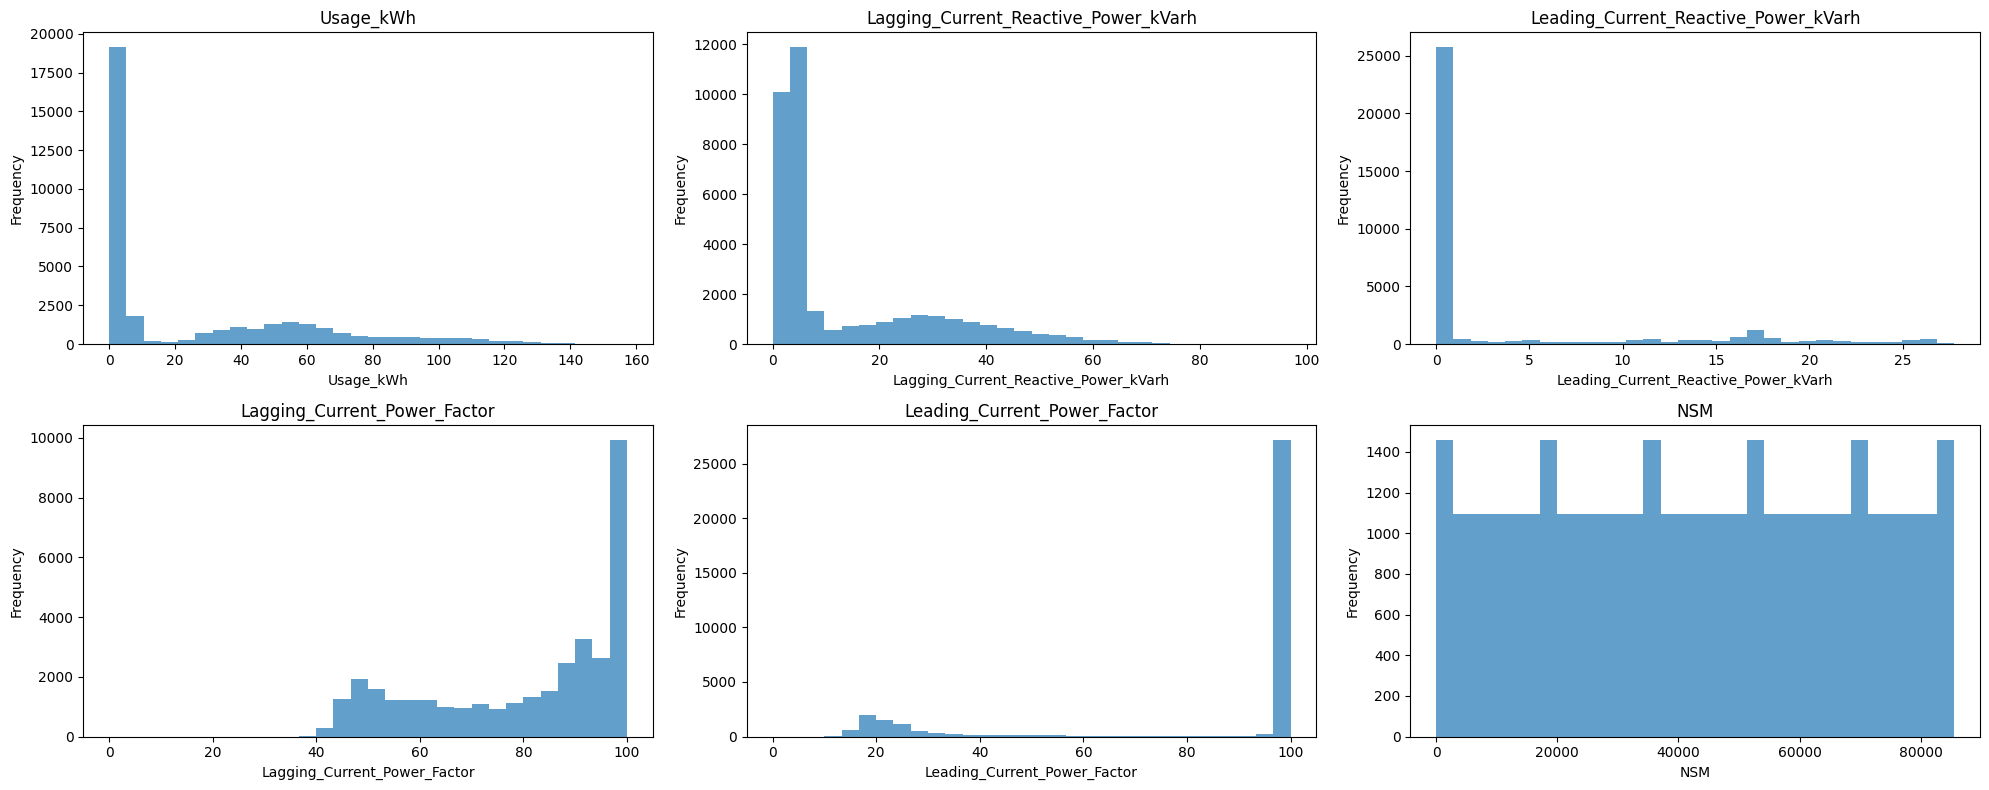

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_rows = 2
n_cols = (len(num_cols) + 1) // 2 
plt.figure(figsize=(20, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df[col], bins=30, alpha=0.7)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Outliers Analysis

Usage_kWh: Moderate outliers present; possible anomalies but overall acceptable distribution.

Lagging_Current_Reactive_Power_kVarh: Noticeable outliers indicating variability in reactive power.

Leading_Current_Reactive_Power_kVarh: Very high outliers; highly skewed feature needing careful handling.

Lagging_Current_Power_Factor: Almost no outliers; stable and reliable feature.

Leading_Current_Power_Factor: High outliers due to narrow range; may not be true anomalies.

NSM: No outliers; uniformly distributed time-based feature.

In [23]:
# Capping Usage_kWh, Lagging_Current_Reactive_Power_kVarh Feature
cols = ['Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

In [24]:
# NSM has huge range from 0 to 86400 (seconds in a day) .
# I used sine and cosine transformation on NSM because it represents time of day, which is linear in nature, and 
# sin/cos helps preserve this to circular relationship.

In [25]:
df["NSM_sin"] = np.sin(2 * np.pi * df["NSM"] / 86400)
df["NSM_cos"] = np.cos(2 * np.pi * df["NSM"] / 86400)

In [26]:
df.drop("NSM", axis=1, inplace=True) 
# droping the original NSM column since we have got NSM_sin and NSM_cos columns

In [27]:
#Converting date format and dividing it in day and month
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df.drop("date", axis=1, inplace=True)

In [29]:
# Month cyclical 
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df.drop("month", axis=1, inplace=True)

## Exploratory Data Analysis

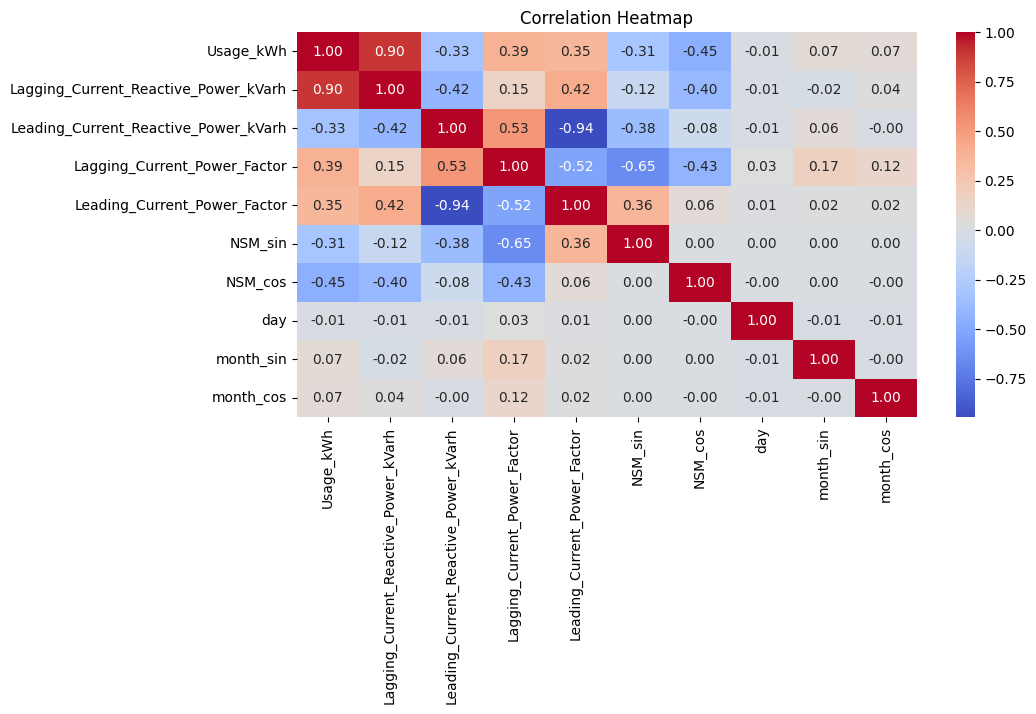

In [30]:
plt.figure(figsize=(10,5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [31]:
# This heatmap shows relationships between all numerical features.
# Darker colors indicate stronger correlation.
# We can see which features strongly impact energy consumption.
# Lagging and leading reactive power show strong relationships with energy usage, which makes sense in industrial systems.

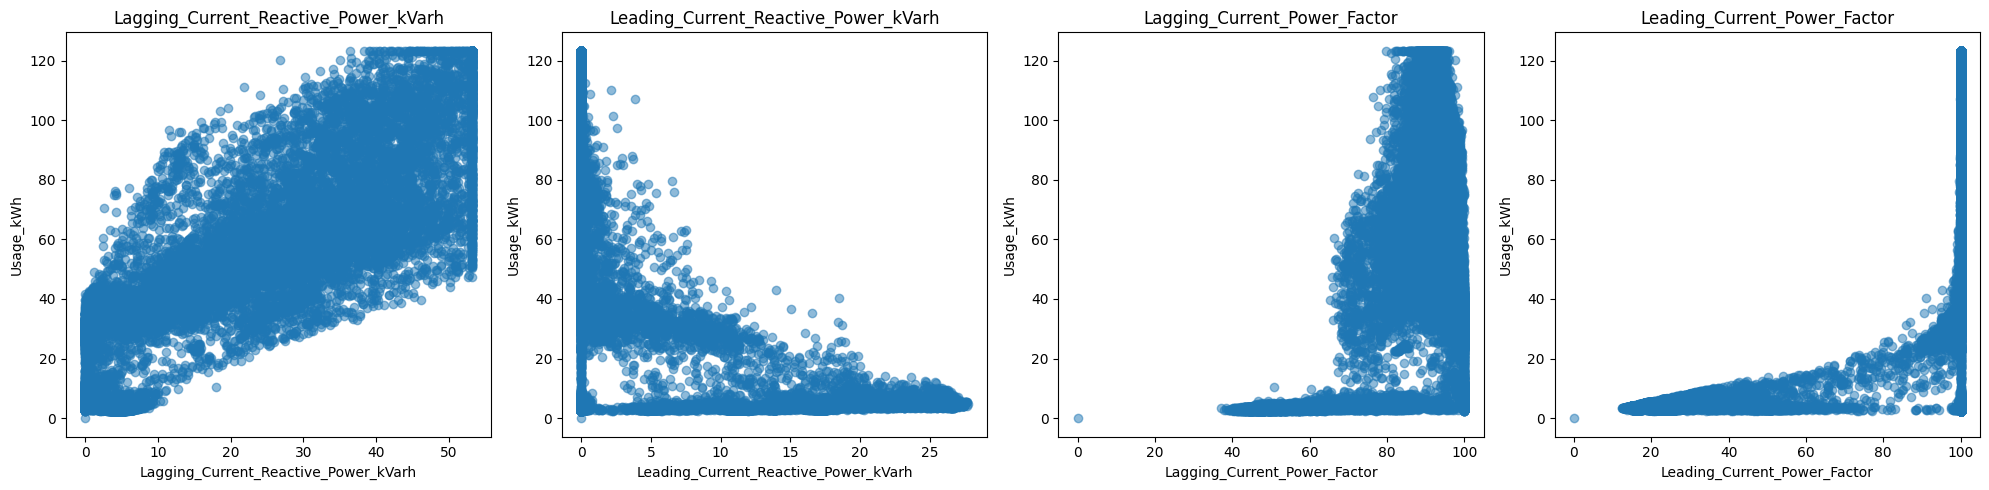

In [32]:
# Features vs load
features = [
    'Lagging_Current_Reactive_Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor'
]
plt.figure(figsize=(20,5))
for i, col in enumerate(features, 1):
    plt.subplot(1, 4, i)
    plt.scatter(df[col], df['Usage_kWh'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Usage_kWh")
    plt.title(col)

plt.tight_layout()
plt.show()

In [33]:
# These plots show how electrical parameters affect energy consumption.
# We observe that as reactive power increases, energy usage also increases.
# Lower power factor can lead to higher energy losses.

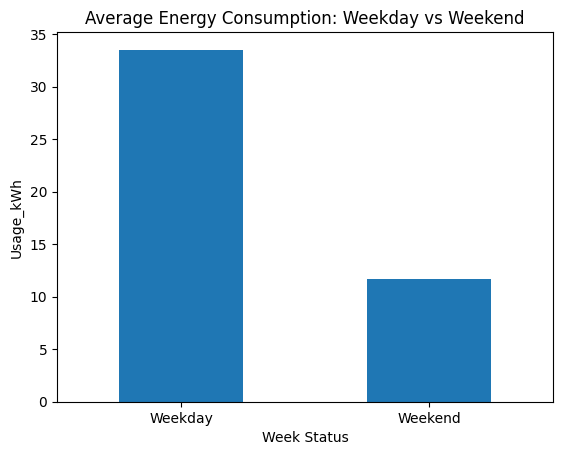

In [34]:
df.groupby('WeekStatus')['Usage_kWh'].mean().plot(kind='bar')

plt.title("Average Energy Consumption: Weekday vs Weekend")
plt.xlabel("Week Status")
plt.ylabel("Usage_kWh")
plt.xticks(rotation=0)
plt.show()

In [35]:
# This plot compares energy consumption between weekdays and weekends.
# We can see that weekdays generally have higher energy usage due to industrial activity.

## Feature Selection

In [36]:
y = df["Usage_kWh"] # target varaible

In [37]:
X = df.drop(["Usage_kWh"],axis=1) # input features

## Split the Data

In [38]:
# splitting the data into training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Model Building & Evaluation

# KNN Regressor

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols), #Standard scaler because equal important to all features ,works for low outliers
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols) # Onehot encoding because it convert them into numbers without meaning distortion(no order)
])
# Pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

In [41]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}
knn_cv = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
knn_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [42]:
# for knn i used grid search cv because it has Small parameter space and works faster

In [43]:
print("Best Params:", knn_cv.best_params_)
print("Best CV Score:", knn_cv.best_score_)

Best Params: {'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'distance'}
Best CV Score: 0.9666035642312227


In [44]:
y_pred = knn_cv.predict(X_test)
y_pred_train = knn_cv.predict(X_train)

In [45]:
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
print("K NEAREST NEIGHBORS REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

K NEAREST NEIGHBORS REGRESSION
R2 Score testing: 0.9694468531363577
R2 Score training: 0.9999995455055547
Mean Absolute Error: 2.6183540741320086
Mean Squared Error 34.22020716414411


In [46]:
# Model is performing very well, but slightly overfitting

# Decision Tree Regression

In [47]:
from sklearn.tree import DecisionTreeRegressor
pipe1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [48]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
tree_cv = RandomizedSearchCV(pipe1, param_grid, cv=5, n_jobs=-1)
tree_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [49]:
# for decision tree i used RandomizedSearch because is faster and avoids overfitting from brute force grid

In [50]:
print("Best Params:", tree_cv.best_params_)
print("Best CV Score:", tree_cv.best_score_)

Best Params: {'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best CV Score: 0.9938510485563677


In [51]:
y_pred = tree_cv.predict(X_test)
y_pred_train = tree_cv.predict(X_train)

In [52]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print("DECISION TREE REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

DECISION TREE REGRESSION
R2 Score testing: 0.9945428249472016
R2 Score training: 0.9965914455890316
Mean Absolute Error: 1.1099897790457378
Mean Squared Error 6.112157993780493


In [53]:
# Extremely high accuracy ie model fits data very well

# Linear Regression

In [54]:
# for linear regression we dont tune it beacause It has NO real hyperparameters.

In [55]:
# we can only tune linear regression using Ridge and lasso 

## Ridge Regression

In [56]:
from sklearn.linear_model import Ridge,Lasso
pipe_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())])

In [57]:
param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}
ridge_cv = GridSearchCV(pipe_ridge,param_grid,cv=5,scoring="r2",verbose=1)
ridge_cv.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [58]:
print("Best Params:", ridge_cv.best_params_)
print("Best CV:", ridge_cv.best_score_)

Best Params: {'regressor__alpha': 1}
Best CV: 0.9169617343186056


In [59]:
y_pred = ridge_cv.predict(X_test)
y_pred_train = ridge_cv.predict(X_train)

In [60]:
print("RIDGE LINEAR REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

RIDGE LINEAR REGRESSION
R2 Score testing: 0.91429253975559
R2 Score training: 0.9170772472626958
Mean Absolute Error: 6.8518153673970215
Mean Squared Error 95.99427051380061


In [102]:
# similar train and test scores, indicating strong performance with minimal overfitting.

## Lasso Regression

In [103]:
pipe_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso())])

In [62]:
param_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1]
}
lasso_cv = GridSearchCV(pipe_lasso, param_grid, cv=5, scoring="r2",verbose=1)
lasso_cv.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

In [63]:
print("Best Params:", lasso_cv.best_params_)
print("Best CV:", lasso_cv.best_score_)

Best Params: {'regressor__alpha': 0.001}
Best CV: 0.9169616342232706


In [64]:
y_pred_lasso = lasso_cv.predict(X_test)
y_pred_lasso_train = lasso_cv.predict(X_train)

In [65]:
print("LASSO LINEAR REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred_lasso))
print("R2 Score training:", r2_score(y_train, y_pred_lasso_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

LASSO LINEAR REGRESSION
R2 Score testing: 0.9142917591743639
R2 Score training: 0.9170771673780092
Mean Absolute Error: 6.8518153673970215
Mean Squared Error 95.99427051380061


In [101]:
# consistent train and test scores, indicating strong performance with good generalization and feature regularization.

# Random Forest Regression

In [109]:
from sklearn.ensemble import RandomForestRegressor
pipe3 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [110]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [8, 10, 12],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [2, 4],
    'model__max_features': ['sqrt']
}
rf_cv = RandomizedSearchCV(pipe3, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [8, 10, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [2, 4], 'model__min_samples_split': [5, 10], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [68]:
# for random forest i have used RandomizedSearchCV because it has Large hyperparameter space 

In [111]:
print("Best Params:", rf_cv.best_params_)
print("Best CV Score:", rf_cv.best_score_)

Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 12}
Best CV Score: 0.977964150874145


In [112]:
y_pred = rf_cv.predict(X_test)
y_pred_train = rf_cv.predict(X_train)

In [113]:
print("RANDOM FOREST REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

RANDOM FOREST REGRESSION
R2 Score testing: 0.9794171611312548
R2 Score training: 0.9835766182752056
Mean Absolute Error: 2.4521325022314184
Mean Squared Error 23.053239434161892


In [72]:
# Model showing excellent predictive accuracy and almost perfect generalization on unseen data.

# ADA BOOSTING REGRESSOR

In [73]:
from sklearn.ensemble import AdaBoostRegressor
base_tree = DecisionTreeRegressor(random_state=42)

pipe4 = Pipeline([
    ('preprocessor', preprocessor),
    ('ada', AdaBoostRegressor(estimator=base_tree,random_state=42))
])

In [74]:
param_grid = {
    'ada__n_estimators': [50, 100, 200],
    'ada__learning_rate': [0.01, 0.1, 0.5],
    'ada__estimator__max_depth': [2, 3, 4]
}
ada_cv = GridSearchCV(pipe4, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
ada_cv.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ada__estimator__max_depth': [2, 3, ...], 'ada__learning_rate': [0.01, 0.1, ...], 'ada__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [75]:
# for ada boosting regressor used grid search cv because it has small parameter space

In [76]:
print("Best Params:", ada_cv.best_params_)
print("Best CV Score:", ada_cv.best_score_)

Best Params: {'ada__estimator__max_depth': 4, 'ada__learning_rate': 0.1, 'ada__n_estimators': 200}
Best CV Score: 0.9812039674461491


In [77]:
y_pred = ada_cv.predict(X_test)
y_pred_train = ada_cv.predict(X_train)

In [78]:
print("ADA BOOSTIONG REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

ADA BOOSTIONG REGRESSION
R2 Score testing: 0.9818724233548674
R2 Score training: 0.9820986111464332
Mean Absolute Error: 2.8103015268343827
Mean Squared Error 20.303290883549618


In [104]:
# very low error and nearly identical train/test scores, indicating excellent performance and strong generalization.

# GRADIENT DESCANT REGRESSION

In [80]:
from sklearn.linear_model import SGDRegressor
pipe5 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(random_state=42))
])

In [81]:
param_grid = {
    'regressor__alpha': [0.0001, 0.001, 0.01],
    'regressor__penalty': ['l2', 'l1', 'elasticnet'],
    'regressor__learning_rate': ['constant', 'adaptive'],
    'regressor__eta0': [0.001, 0.01, 0.1],
    'regressor__max_iter': [1000, 1500],
    'regressor__tol': [1e-3, 1e-4]
}
gd_cv = GridSearchCV(pipe5, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
gd_cv.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.0001, 0.001, ...], 'regressor__eta0': [0.001, 0.01, ...], 'regressor__learning_rate': ['constant', 'adaptive'], 'regressor__max_iter': [1000, 1500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [82]:
# for Stochastic gradient descant i have used grid search cv because its a sensitive model and has few but important parameters

In [83]:
print("Best Params:", gd_cv.best_params_)
print("Best CV Score:", gd_cv.best_score_)

Best Params: {'regressor__alpha': 0.01, 'regressor__eta0': 0.001, 'regressor__learning_rate': 'adaptive', 'regressor__max_iter': 1000, 'regressor__penalty': 'l1', 'regressor__tol': 0.0001}
Best CV Score: 0.916966530946285


In [84]:
y_pred = gd_cv.predict(X_test)
y_pred_train = gd_cv.predict(X_train)

In [85]:
print("STOCHASTIC GRADIENT DESCANT REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

STOCHASTIC GRADIENT DESCANT REGRESSION
R2 Score testing: 0.9142685781245329
R2 Score training: 0.9170703065412126
Mean Absolute Error: 6.851252730741539
Mean Squared Error 96.02110807598119


In [105]:
# consistent train and test scores, indicating stable performance and good generalization similar to linear models.

# XG BOOSTING REGRESSION

In [118]:
from xgboost import XGBRegressor
pipe6 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror',random_state=42))
])

In [119]:
param_grid = {
    'regressor__n_estimators': [100, 150, 200],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}
xg_cv = RandomizedSearchCV(pipe6, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
xg_cv.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__colsample_bytree': [0.8, 1.0], 'regressor__learning_rate': [0.05, 0.1], 'regressor__max_depth': [3, 5], 'regressor__n_estimators': [100, 150, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [120]:
# for xg boosting used randomizedsearch because it has many hyperparamters and has high risk of overfitting

In [121]:
print("Best Params:", xg_cv.best_params_)
print("Best CV Score:", xg_cv.best_score_)

Best Params: {'regressor__subsample': 1.0, 'regressor__n_estimators': 150, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 1.0}
Best CV Score: 0.9969261569533376


In [122]:
y_pred = xg_cv.predict(X_test)
y_pred_train = xg_cv.predict(X_train)

In [123]:
print("XG BOOSTING REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))

XG BOOSTING REGRESSION
R2 Score testing: 0.9973415351679744
R2 Score training: 0.997833911736918
Mean Absolute Error: 0.7052938687620623
Mean Squared Error 2.9775400123764113


In [106]:
# extremely low error, but slightly higher training score suggests mild overfitting while still delivering top performance.

# BEST MODEL R2 SCORE

In [124]:
modelss = {
    "KNeighborRegressor":knn_cv,
    "DecisionTreeRegreesor":tree_cv,
    "RidgeRegression":ridge_cv,
    "LassoRegression":lasso_cv,
    "RandomForestRegressor":rf_cv,
    "AdaBoostingRegressor":ada_cv,
    "SGDRegressor": gd_cv,
    "XGBoostRegressor": xg_cv
}

In [125]:
# Selecting the best model based on cross-validation R² score

In [126]:
r2_scores = {}

for name, model in modelss.items():
    r2_scores[name] = model.best_score_

In [127]:
best_model_name = max(r2_scores, key=r2_scores.get)
best_r2 = r2_scores[best_model_name]

print("Best Model:", best_model_name)
print("Best R2 Score:", best_r2)

Best Model: XGBoostRegressor
Best R2 Score: 0.9969261569533376


## Conclusion
- Machine learning can predict energy consumption effectively
- #### XGBoost Regressor achieved the best performance based on cross-validation R² score, making it the final selected model.
- XGBoost also showed strong generalization with minimal difference between training and testing performance.

### Why XGBoost performing best

In problems like steel industry energy consumption:

Data has non-linear relationships

Features interact in complex ways (reactive power,temperature, power factors, etc.)

--> XGBoost is designed for this:

Captures non-linearity

Uses boosting → improves weak learners

Handles noise better

In [129]:
import pickle
with open("best_model.pkl", "wb") as file:
    pickle.dump(modelss[best_model_name], file)
# Saving the best performing model (XGBoost) for deployment
print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.pkl


In [1]:
import warnings
warnings.filterwarnings('ignore')